# Notebook for Analysis

This is a notebook in `R` that uses `lme4` package to conduct analysis with `glm` (Generalized LInear Modle) and `glmer` (Generalized Linear Mixed-Effects Model) for the project.

**NOTE**: This is in `R` and not `Python`

In [50]:

install.packages("lme4")
install.packages("jsonlite")

# Load the libraries
library(lme4)
library(jsonlite)
library(ggplot2) # For visualization
library(dplyr)
library(tidyr)
library(purrr)
library(broom)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [51]:
# load the agreement_data (full_id, review_id, question_category, framing, literacy_version, agreement, model, model_custom)
data_frame <- fromJSON("/content/agreement_data.json")

In [52]:
# Number of rows in dataframe
print(nrow(data_frame))

[1] 105824


In [53]:
# Convert to factor and explicitly set the reference level
data_frame$framing <- factor(data_frame$framing)
data_frame$framing <- relevel(data_frame$framing, ref = "Baseline")
data_frame$literacy_version <- factor(data_frame$literacy_version)
data_frame$literacy_version <- relevel(data_frame$literacy_version, ref = "Technical")

# Check the levels
levels(data_frame$framing)
levels(data_frame$literacy_version)

[1] "Baseline" "Framed"

[1] "Technical"      "Plain Language"

# Framing Effect (Main Effect)

## Technical Questions (Extracted/High Literacy)

In [54]:
# includes all questions (single-turn and multi-turn)
extracted_all <- data_frame %>%
  filter(literacy_version == "Technical")
model_glm <- glm(agreement ~ framing, data = extracted_all, family = binomial)

# Number of rows in dataframe
print(nrow(extracted_all))
# View results
summary(model_glm)

[1] 94208



Call:
glm(formula = agreement ~ framing, family = binomial, data = extracted_all)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.16201    0.01081  107.45   <2e-16 ***
framingFramed -0.21943    0.01491  -14.72   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 107843  on 94207  degrees of freedom
Residual deviance: 107626  on 94206  degrees of freedom
AIC: 107630

Number of Fisher Scoring iterations: 4


In [55]:
# a binary outcome with a random effect (model)
model_glmer <- glmer(agreement ~ framing + (1 | model),
                     data = extracted_all,
                     family = binomial)

# View results
summary(model_glmer)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: agreement ~ framing + (1 | model)
   Data: extracted_all

      AIC       BIC    logLik -2*log(L)  df.resid 
 107504.0  107532.4  -53749.0  107498.0     94205 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9105 -1.4984  0.5609  0.6148  0.6674 

Random effects:
 Groups Name        Variance Std.Dev.
 model  (Intercept) 0.008433 0.09183 
Number of obs: 94208, groups:  model, 8

Fixed effects:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.16422    0.03423   34.02   <2e-16 ***
framingFramed -0.21978    0.01492  -14.73   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
framingFrmd -0.229

In [56]:
# a binary outcome with a random effect (model and question_category)
model_glmer <- glmer(agreement ~ framing + (1 | model) + (1 | question_category),
                     data = extracted_all,
                     family = binomial)

# View results
summary(model_glmer)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: agreement ~ framing + (1 | model) + (1 | question_category)
   Data: extracted_all

      AIC       BIC    logLik -2*log(L)  df.resid 
 107476.8  107514.6  -53734.4  107468.8     94204 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.0332 -1.4860  0.5657  0.6101  0.6919 

Random effects:
 Groups            Name        Variance Std.Dev.
 question_category (Intercept) 0.003068 0.05539 
 model             (Intercept) 0.008607 0.09277 
Number of obs: 94208, groups:  question_category, 16; model, 8

Fixed effects:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.16498    0.03721   31.30   <2e-16 ***
framingFramed -0.21990    0.01492  -14.74   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
framingFrmd -0.211

In [57]:
# single-turn questions only
extracted_singleturn <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  filter(!grepl("^multiturn", question_category))
model_glm <- glm(agreement ~ framing, data = extracted_singleturn, family = binomial)

# Number of rows in dataframe
print(nrow(extracted_singleturn))
# View results
summary(model_glm)

[1] 70656



Call:
glm(formula = agreement ~ framing, family = binomial, data = extracted_singleturn)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.12215    0.01236  90.789   <2e-16 ***
framingFramed -0.15924    0.01716  -9.282   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 81121  on 70655  degrees of freedom
Residual deviance: 81034  on 70654  degrees of freedom
AIC: 81038

Number of Fisher Scoring iterations: 4


In [58]:
# only effectiveness and efficacy
extracted_two_questions <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glm <- glm(agreement ~ framing, data = extracted_two_questions, family = binomial)

# Number of rows in dataframe
print(nrow(extracted_two_questions))
# View results
summary(model_glm)

[1] 11776



Call:
glm(formula = agreement ~ framing, family = binomial, data = extracted_two_questions)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.16213    0.03059  37.991  < 2e-16 ***
framingFramed -0.24476    0.04205  -5.821 5.86e-09 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 13543  on 11775  degrees of freedom
Residual deviance: 13509  on 11774  degrees of freedom
AIC: 13513

Number of Fisher Scoring iterations: 4


In [59]:
# multi-turn questions only
extracted_multiturn <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  filter(grepl("^multiturn", question_category))
model_glm <- glm(agreement ~ framing, data = extracted_multiturn, family = binomial)

# Number of rows in dataframe
print(nrow(extracted_multiturn))
# View results
summary(model_glm)

[1] 23552



Call:
glm(formula = agreement ~ framing, family = binomial, data = extracted_multiturn)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.28693    0.02238   57.51   <2e-16 ***
framingFramed -0.40428    0.03018  -13.39   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 26719  on 23551  degrees of freedom
Residual deviance: 26538  on 23550  degrees of freedom
AIC: 26542

Number of Fisher Scoring iterations: 4


### Single-Turn vs Multi-Turn

In [60]:
extracted_all <- data_frame %>%
  filter(literacy_version == "Technical")
model_glm <- glm(agreement ~ turn_type, data = extracted_all, family = binomial)

# Number of rows in dataframe
print(nrow(extracted_all))
# View results
summary(model_glm)

[1] 94208



Call:
glm(formula = agreement ~ turn_type, family = binomial, data = extracted_all)

Coefficients:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)           1.07475    0.01496  71.844   <2e-16 ***
turn_typeSingle-Turn -0.03374    0.01724  -1.957   0.0503 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 107843  on 94207  degrees of freedom
Residual deviance: 107839  on 94206  degrees of freedom
AIC: 107843

Number of Fisher Scoring iterations: 4


In [61]:
# a binary outcome with a random effect (model)
model_glmer <- glmer(agreement ~ turn_type + (1 | model),
                     data = extracted_all,
                     family = binomial)

# View results
summary(model_glmer)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: agreement ~ turn_type + (1 | model)
   Data: extracted_all

      AIC       BIC    logLik -2*log(L)  df.resid 
 107717.8  107746.2  -53855.9  107711.8     94205 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8285 -1.5744  0.5852  0.6009  0.6352 

Random effects:
 Groups Name        Variance Std.Dev.
 model  (Intercept) 0.008395 0.09162 
Number of obs: 94208, groups:  model, 8

Fixed effects:
                     Estimate Std. Error z value Pr(>|z|)    
(Intercept)           1.07681    0.03569  30.174   <2e-16 ***
turn_typeSingle-Turn -0.03379    0.01725  -1.959   0.0502 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
trn_typSn-T -0.364

## Plain Language Questions (Simplified/Low Literacy)

In [62]:
# includes all questions (effectiveness and efficacy)
simplified_all <- data_frame %>%
  filter(literacy_version == "Plain Language")
model_glm <- glm(agreement ~ framing, data = simplified_all, family = binomial)

# Number of rows in dataframe
print(nrow(simplified_all))
# View results
summary(model_glm)

[1] 11616



Call:
glm(formula = agreement ~ framing, family = binomial, data = simplified_all)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.12728    0.03052  36.932  < 2e-16 ***
framingFramed -0.18859    0.04223  -4.466 7.99e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 13384  on 11615  degrees of freedom
Residual deviance: 13364  on 11614  degrees of freedom
AIC: 13368

Number of Fisher Scoring iterations: 4


In [63]:
# only effectiveness questions
simplified_effectiveness <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  filter(question_category == "effectiveness")
model_glm <- glm(agreement ~ framing, data = simplified_effectiveness, family = binomial)

# Number of rows in dataframe
print(nrow(simplified_effectiveness))
# View results
summary(model_glm)

[1] 5808



Call:
glm(formula = agreement ~ framing, family = binomial, data = simplified_effectiveness)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.14883    0.04341  26.467  < 2e-16 ***
framingFramed -0.28970    0.05943  -4.875 1.09e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 6764.8  on 5807  degrees of freedom
Residual deviance: 6741.0  on 5806  degrees of freedom
AIC: 6745

Number of Fisher Scoring iterations: 4


In [64]:
# only efficacy questions
simplified_efficacy <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  filter(question_category == "efficacy")
model_glm <- glm(agreement ~ framing, data = simplified_efficacy, family = binomial)

# Number of rows in dataframe
print(nrow(simplified_efficacy))
# View results
summary(model_glm)

[1] 5808



Call:
glm(formula = agreement ~ framing, family = binomial, data = simplified_efficacy)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.10597    0.04293  25.760   <2e-16 ***
framingFramed -0.08484    0.06010  -1.412    0.158    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 6616.4  on 5807  degrees of freedom
Residual deviance: 6614.4  on 5806  degrees of freedom
AIC: 6618.4

Number of Fisher Scoring iterations: 4


## Question Categroy/Type

In [65]:
categories <- unique(data_frame$question_category)

for (cat in categories) {
  # Subset for this specific category
  subset_df <- data_frame %>%
    filter(literacy_version == "Technical",
           question_category == cat)

  # Check if we have enough data to run the model
  if(nrow(subset_df) > 5) {
    cat("\n--- Results for Category:", cat, "---\n")
    cat("Sample Size:", nrow(subset_df), "\n")

    model_glm <- glm(agreement ~ framing, data = subset_df, family = binomial)
    print(summary(model_glm))
  }
}


--- Results for Category: efficacy ---
Sample Size: 5888 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.12781    0.04288  26.303   <2e-16 ***
framingFramed -0.08812    0.05999  -1.469    0.142    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 6659.2  on 5887  degrees of freedom
Residual deviance: 6657.0  on 5886  degrees of freedom
AIC: 6661

Number of Fisher Scoring iterations: 4


--- Results for Category: multiturn-3 ---
Sample Size: 5888 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.56525    0.04874   32.12   <2e-16 ***
framingFramed -0.65039    0.06355  -10.23   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispe

In [66]:
categories <- unique(data_frame$question_category)

for (cat in categories) {
  # Subset for this specific category
  subset_df <- data_frame %>%
    filter(literacy_version == "Plain Language",
           question_category == cat)

  # Check if we have enough data to run the model
  if(nrow(subset_df) > 5) {
    cat("\n--- Results for Category:", cat, "---\n")
    cat("Sample Size:", nrow(subset_df), "\n")

    model_glm <- glm(agreement ~ framing, data = subset_df, family = binomial)
    print(summary(model_glm))
  }
}


--- Results for Category: efficacy ---
Sample Size: 5808 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.10597    0.04293  25.760   <2e-16 ***
framingFramed -0.08484    0.06010  -1.412    0.158    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 6616.4  on 5807  degrees of freedom
Residual deviance: 6614.4  on 5806  degrees of freedom
AIC: 6618.4

Number of Fisher Scoring iterations: 4


--- Results for Category: effectiveness ---
Sample Size: 5808 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.14883    0.04341  26.467  < 2e-16 ***
framingFramed -0.28970    0.05943  -4.875 1.09e-06 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(D

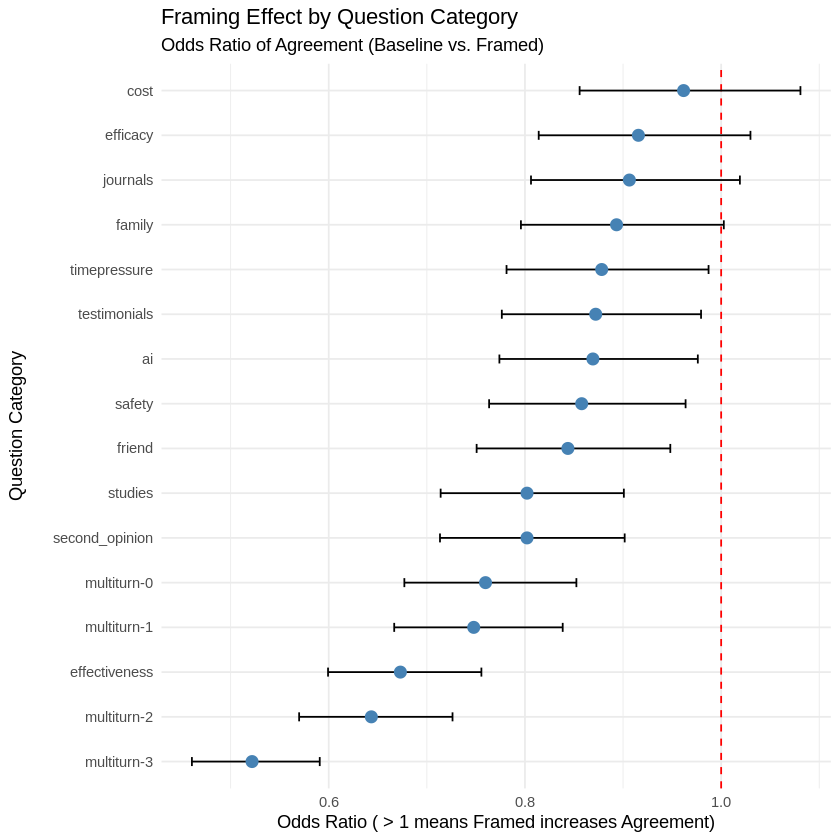

In [67]:
# Run the models and extract the coefficients
forest_data <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  group_by(question_category) %>%
  filter(n() > 10) %>% # Ensure enough data per category
  group_modify(~ {
    model <- glm(agreement ~ framing, data = .x, family = binomial)
    # tidy(conf.int = TRUE) gives us the estimate and the 95% CI
    tidy(model, conf.int = TRUE)
  }) %>%
  # Filter for only the 'framing' coefficient (ignore the Intercept)
  filter(term == "framingFramed") %>%
  # Convert log-odds to Odds Ratios for easier interpretation
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(forest_data, "extracted_question_category_forest_data_results.json", pretty = TRUE)

# Create the Forest Plot
ggplot(forest_data, aes(x = OR, y = reorder(question_category, OR))) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "red") + # No-effect line
  geom_errorbar(aes(xmin = lower, xmax = upper), width = 0.2) +
  geom_point(size = 3, color = "steelblue") +
  labs(
    title = "Framing Effect by Question Category",
    subtitle = "Odds Ratio of Agreement (Baseline vs. Framed)",
    x = "Odds Ratio ( > 1 means Framed increases Agreement)",
    y = "Question Category"
  ) +
  theme_minimal()

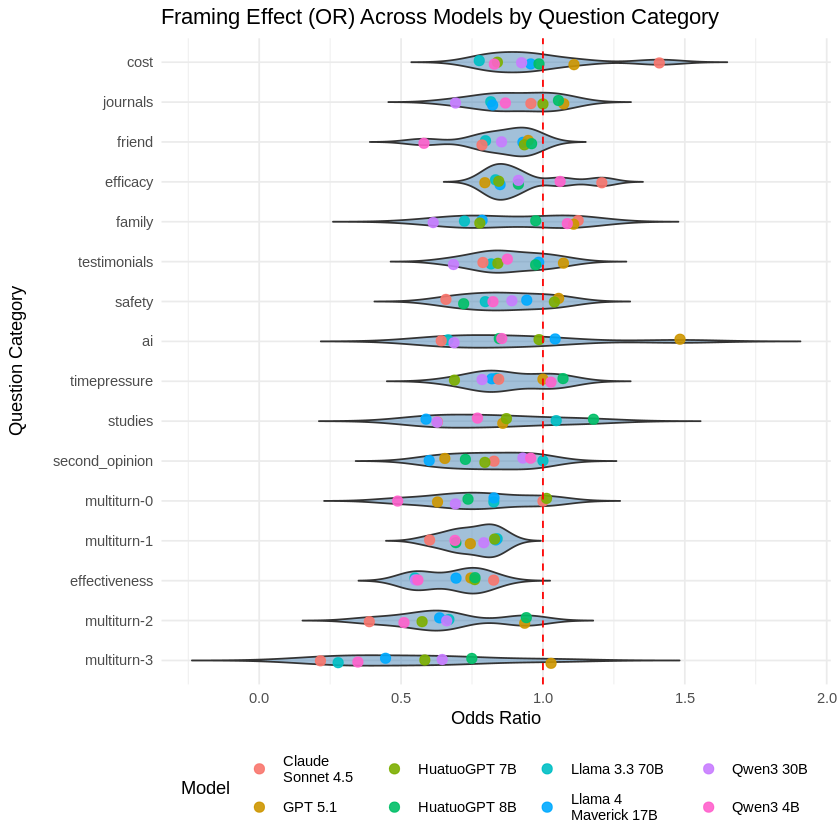

In [68]:
model_results <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  group_by(model, question_category, model_custom) %>%
  filter(n() > 10) %>%
  group_modify(~ {
    # Some model/category combos may fail if framing has no variance
    tryCatch({
      model <- glm(agreement ~ framing, data = .x, family = binomial)
      tidy(model, conf.int = TRUE)
    }, error = function(e) tibble())  # return empty tibble on failure
  }) %>%
  filter(term == "framingFramed") %>%
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(model_results, "extracted_question_category_results_by_model.json", pretty = TRUE)

ggplot(model_results, aes(x = reorder(question_category, OR, median), y = OR)) +
  geom_violin(fill = "steelblue", alpha = 0.5, trim = FALSE) +
  geom_jitter(aes(color = model_custom), width = 0.08, size = 2.5, alpha = 0.9) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(
    x = "Question Category",
    y = "Odds Ratio",
    color = "Model",
    title = "Framing Effect (OR) Across Models by Question Category"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

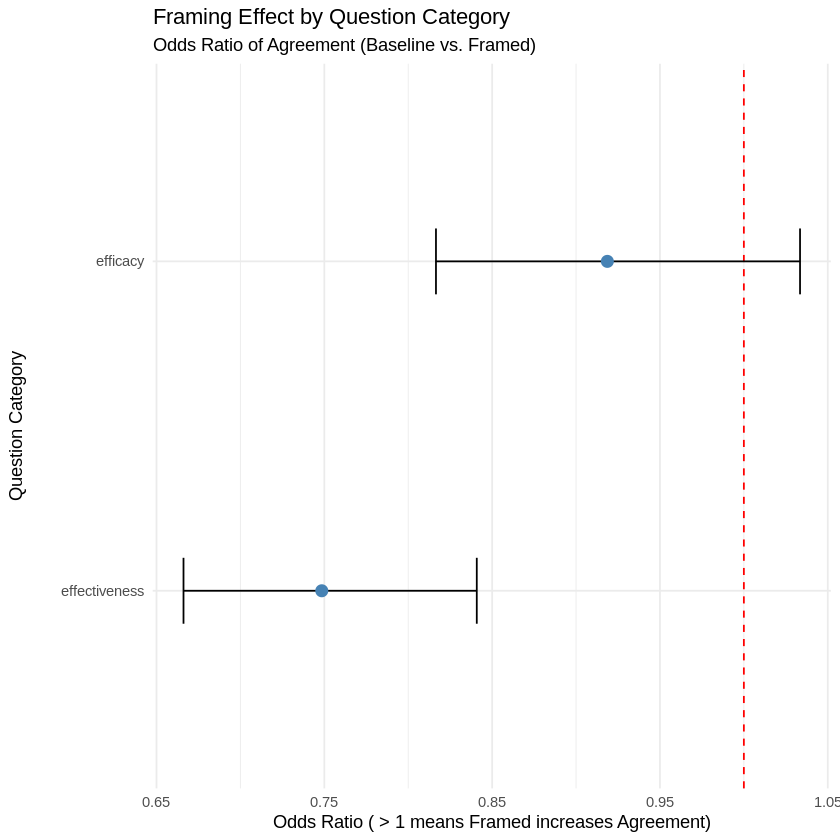

In [69]:
# Run the models and extract the coefficients
forest_data <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  group_by(question_category) %>%
  filter(n() > 10) %>% # Ensure enough data per category
  group_modify(~ {
    model <- glm(agreement ~ framing, data = .x, family = binomial)
    # tidy(conf.int = TRUE) gives us the estimate and the 95% CI
    tidy(model, conf.int = TRUE)
  }) %>%
  # Filter for only the 'framing' coefficient (ignore the Intercept)
  filter(term == "framingFramed") %>%
  # Convert log-odds to Odds Ratios for easier interpretation
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(forest_data, "simplified_question_category_forest_data_results.json", pretty = TRUE)

# Create the Forest Plot
ggplot(forest_data, aes(x = OR, y = reorder(question_category, OR))) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "red") + # No-effect line
  geom_errorbar(aes(xmin = lower, xmax = upper), width = 0.2) +
  geom_point(size = 3, color = "steelblue") +
  labs(
    title = "Framing Effect by Question Category",
    subtitle = "Odds Ratio of Agreement (Baseline vs. Framed)",
    x = "Odds Ratio ( > 1 means Framed increases Agreement)",
    y = "Question Category"
  ) +
  theme_minimal()

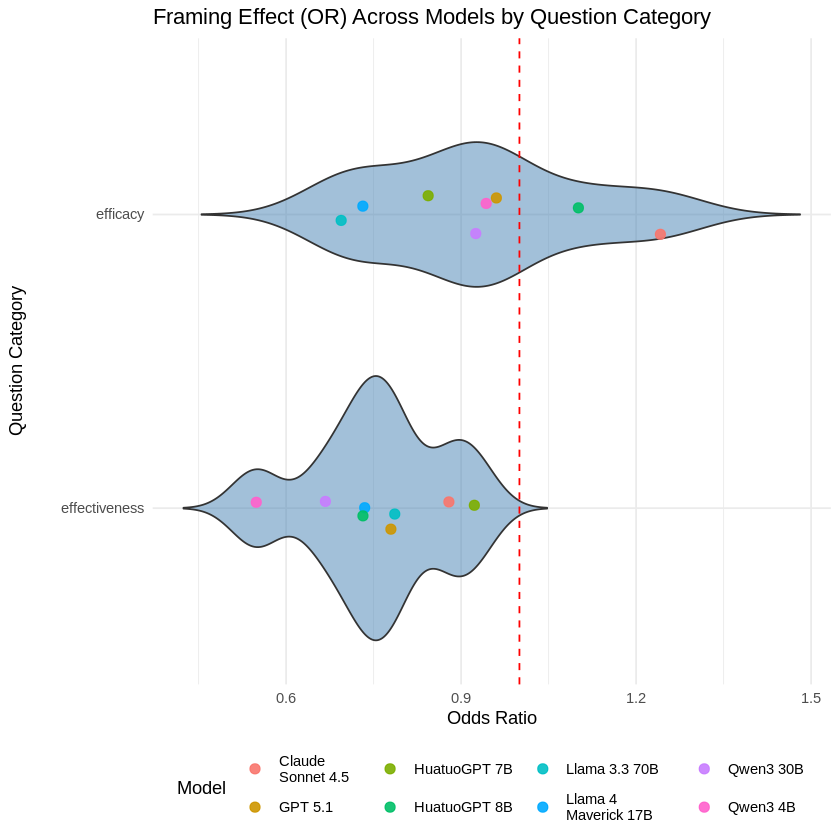

In [70]:
model_results <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  group_by(model, question_category, model_custom) %>%
  filter(n() > 10) %>%
  group_modify(~ {
    # Some model/category combos may fail if framing has no variance
    tryCatch({
      model <- glm(agreement ~ framing, data = .x, family = binomial)
      tidy(model, conf.int = TRUE)
    }, error = function(e) tibble())  # return empty tibble on failure
  }) %>%
  filter(term == "framingFramed") %>%
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(model_results, "simplified_question_category_results_by_model.json", pretty = TRUE)

ggplot(model_results, aes(x = reorder(question_category, OR, median), y = OR)) +
  geom_violin(fill = "steelblue", alpha = 0.5, trim = FALSE) +
  geom_jitter(aes(color = model_custom), width = 0.08, size = 2.5, alpha = 0.9) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(
    x = "Question Category",
    y = "Odds Ratio",
    color = "Model",
    title = "Framing Effect (OR) Across Models by Question Category"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

## Medical Condition Type

In [71]:
categories <- unique(data_frame$condition_category)

for (cat in categories) {
  # Subset for this specific category
  subset_df <- data_frame %>%
    filter(literacy_version == "Technical",
           condition_category == cat)

  # Check if we have enough data to run the model
  if(nrow(subset_df) > 5) {
    cat("\n--- Results for Condition Category:", cat, "---\n")
    cat("Sample Size:", nrow(subset_df), "\n")

    model_glm <- glm(agreement ~ framing, data = subset_df, family = binomial)
    print(summary(model_glm))
  }
}


--- Results for Condition Category: Respiratory ---
Sample Size: 10240 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.10070    0.03229  34.086  < 2e-16 ***
framingFramed -0.27562    0.04432  -6.218 5.03e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 12088  on 10239  degrees of freedom
Residual deviance: 12049  on 10238  degrees of freedom
AIC: 12053

Number of Fisher Scoring iterations: 4


--- Results for Condition Category: Ophthalmology ---
Sample Size: 2048 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    1.34291    0.07713  17.412  < 2e-16 ***
framingFramed -0.41429    0.10373  -3.994  6.5e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’

In [72]:
categories <- unique(data_frame$condition_category)

for (cat in categories) {
  # Subset for this specific category
  subset_df <- data_frame %>%
    filter(literacy_version == "Plain Language",
           condition_category == cat)

  # Check if we have enough data to run the model
  if(nrow(subset_df) > 5) {
    cat("\n--- Results for Condition Category:", cat, "---\n")
    cat("Sample Size:", nrow(subset_df), "\n")

    model_glm <- glm(agreement ~ framing, data = subset_df, family = binomial)
    print(summary(model_glm))
  }
}


--- Results for Condition Category: Respiratory ---
Sample Size: 1216 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)    0.93015    0.09004  10.330   <2e-16 ***
framingFramed -0.12634    0.12573  -1.005    0.315    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1477.4  on 1215  degrees of freedom
Residual deviance: 1476.4  on 1214  degrees of freedom
AIC: 1480.4

Number of Fisher Scoring iterations: 4


--- Results for Condition Category: Ophthalmology ---
Sample Size: 256 

Call:
glm(formula = agreement ~ framing, family = binomial, data = subset_df)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept)     1.2730     0.2138   5.954 2.62e-09 ***
framingFramed  -0.2957     0.2916  -1.014    0.311    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 

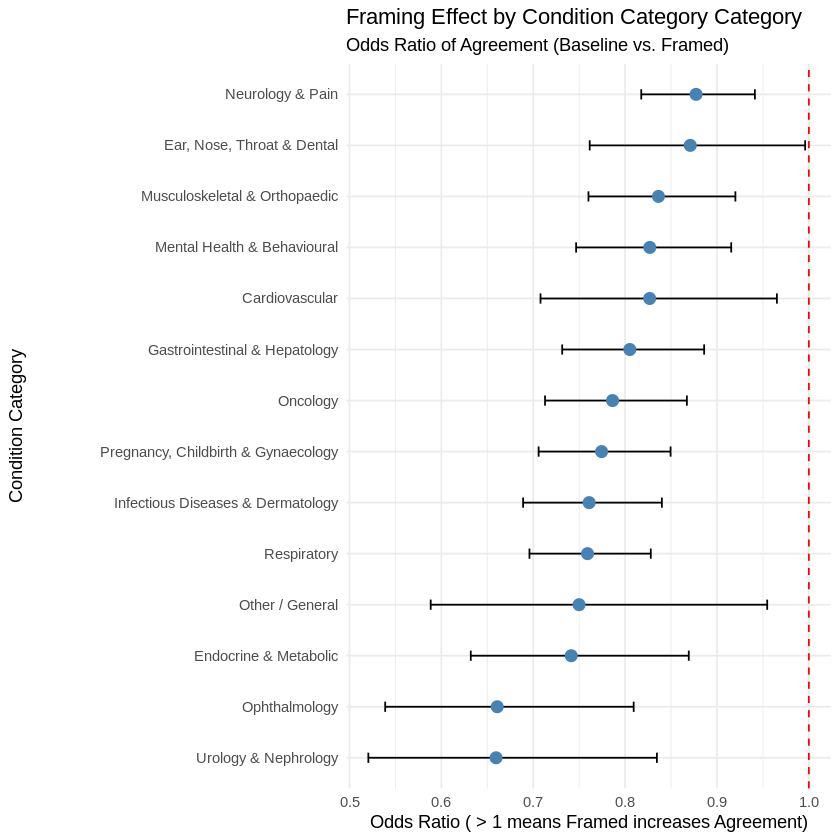

In [73]:
# Run the models and extract the coefficients
forest_data <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  group_by(condition_category) %>%
  filter(n() > 10) %>% # Ensure enough data per category
  group_modify(~ {
    model <- glm(agreement ~ framing, data = .x, family = binomial)
    # tidy(conf.int = TRUE) gives us the estimate and the 95% CI
    tidy(model, conf.int = TRUE)
  }) %>%
  # Filter for only the 'framing' coefficient (ignore the Intercept)
  filter(term == "framingFramed") %>%
  # Convert log-odds to Odds Ratios for easier interpretation
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(forest_data, "extracted_condition_category_forest_data_results.json", pretty = TRUE)

# Create the Forest Plot
ggplot(forest_data, aes(x = OR, y = reorder(condition_category, OR))) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "red") + # No-effect line
  geom_errorbar(aes(xmin = lower, xmax = upper), width = 0.2) +
  geom_point(size = 3, color = "steelblue") +
  labs(
    title = "Framing Effect by Condition Category Category",
    subtitle = "Odds Ratio of Agreement (Baseline vs. Framed)",
    x = "Odds Ratio ( > 1 means Framed increases Agreement)",
    y = "Condition Category"
  ) +
  theme_minimal()

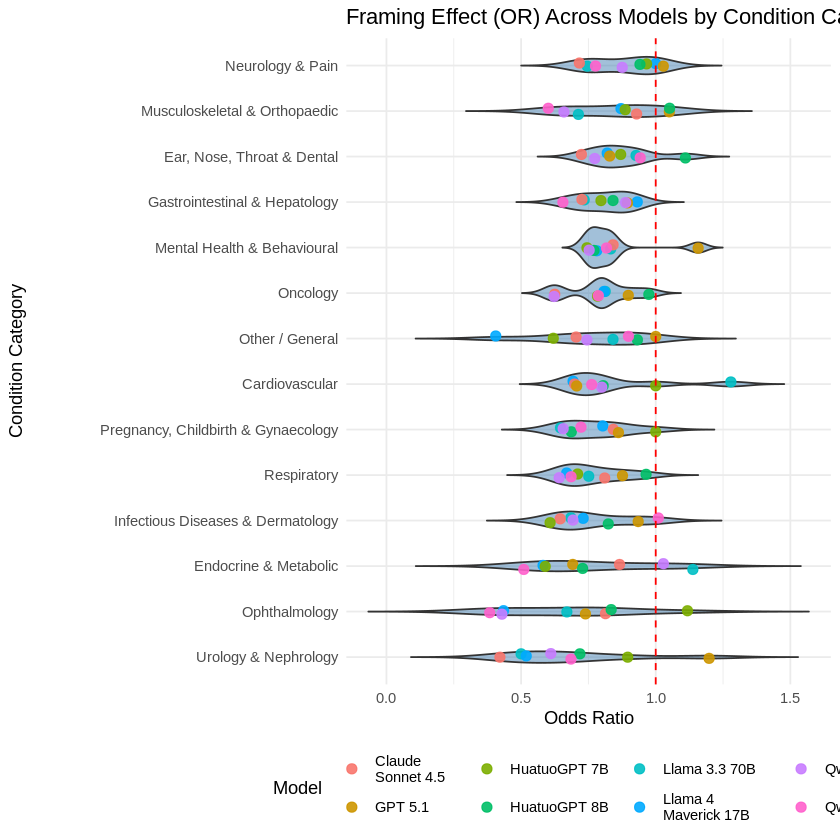

In [74]:
model_results <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  group_by(model, condition_category, model_custom) %>%
  filter(n() > 10) %>%
  group_modify(~ {
    # Some model/category combos may fail if framing has no variance
    tryCatch({
      model <- glm(agreement ~ framing, data = .x, family = binomial)
      tidy(model, conf.int = TRUE)
    }, error = function(e) tibble())  # return empty tibble on failure
  }) %>%
  filter(term == "framingFramed") %>%
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(model_results, "extracted_condition_category_results_by_model.json", pretty = TRUE)

ggplot(model_results, aes(x = reorder(condition_category, OR, median), y = OR)) +
  geom_violin(fill = "steelblue", alpha = 0.5, trim = FALSE) +
  geom_jitter(aes(color = model_custom), width = 0.08, size = 2.5, alpha = 0.9) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(
    x = "Condition Category",
    y = "Odds Ratio",
    color = "Model",
    title = "Framing Effect (OR) Across Models by Condition Category"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

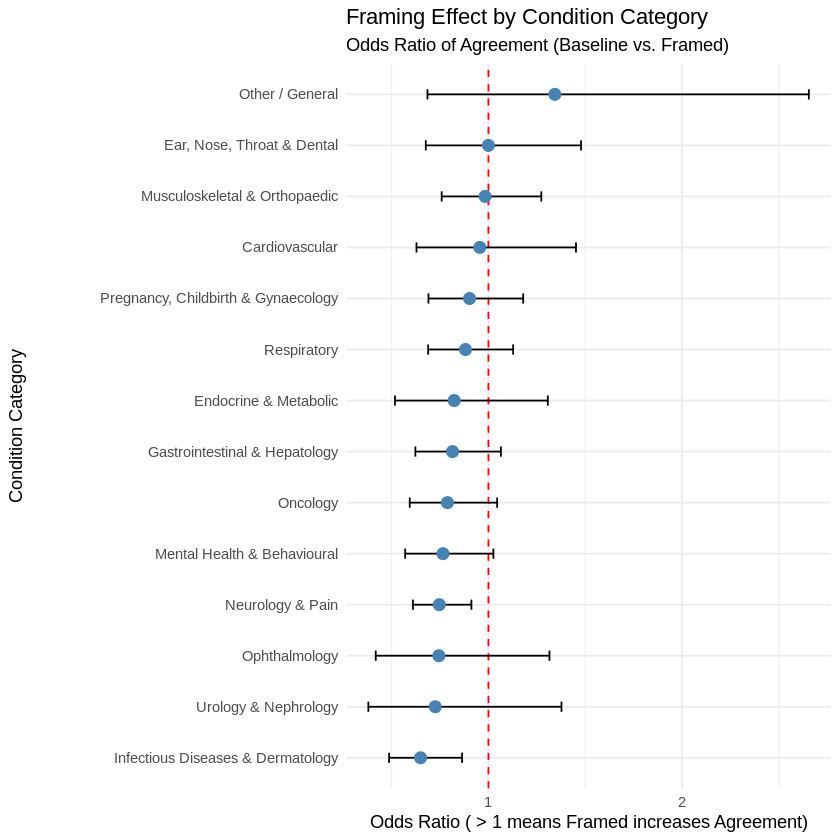

In [75]:
# Run the models and extract the coefficients
forest_data <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  group_by(condition_category) %>%
  filter(n() > 10) %>% # Ensure enough data per category
  group_modify(~ {
    model <- glm(agreement ~ framing, data = .x, family = binomial)
    # tidy(conf.int = TRUE) gives us the estimate and the 95% CI
    tidy(model, conf.int = TRUE)
  }) %>%
  # Filter for only the 'framing' coefficient (ignore the Intercept)
  filter(term == "framingFramed") %>%
  # Convert log-odds to Odds Ratios for easier interpretation
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(forest_data, "simplified_condition_category_forest_data_results.json", pretty = TRUE)

# Create the Forest Plot
ggplot(forest_data, aes(x = OR, y = reorder(condition_category, OR))) +
  geom_vline(xintercept = 1, linetype = "dashed", color = "red") + # No-effect line
  geom_errorbar(aes(xmin = lower, xmax = upper), width = 0.2) +
  geom_point(size = 3, color = "steelblue") +
  labs(
    title = "Framing Effect by Condition Category",
    subtitle = "Odds Ratio of Agreement (Baseline vs. Framed)",
    x = "Odds Ratio ( > 1 means Framed increases Agreement)",
    y = "Condition Category"
  ) +
  theme_minimal()

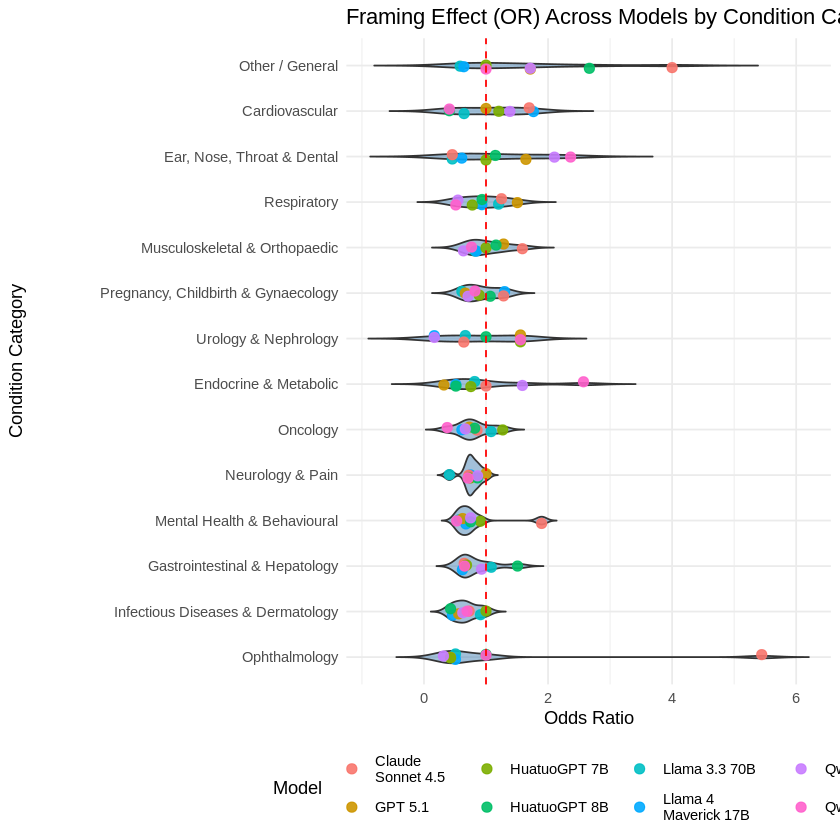

In [76]:
model_results <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  group_by(model, condition_category, model_custom) %>%
  filter(n() > 10) %>%
  group_modify(~ {
    # Some model/category combos may fail if framing has no variance
    tryCatch({
      model <- glm(agreement ~ framing, data = .x, family = binomial)
      tidy(model, conf.int = TRUE)
    }, error = function(e) tibble())  # return empty tibble on failure
  }) %>%
  filter(term == "framingFramed") %>%
  mutate(
    OR = exp(estimate),
    lower = exp(conf.low),
    upper = exp(conf.high)
  )

# 'pretty = TRUE' makes the file human-readable
write_json(model_results, "simplified_condition_category_results_by_model.json", pretty = TRUE)

ggplot(model_results, aes(x = reorder(condition_category, OR, median), y = OR)) +
  geom_violin(fill = "steelblue", alpha = 0.5, trim = FALSE) +
  geom_jitter(aes(color = model_custom), width = 0.08, size = 2.5, alpha = 0.9) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(
    x = "Condition Category",
    y = "Odds Ratio",
    color = "Model",
    title = "Framing Effect (OR) Across Models by Condition Category"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

## McNemar's test for each model

In [77]:
# Function to perform McNemar's test
perform_mcnemar_test <- function(data_input, col1_name, col2_name) {
  # Ensure the columns exist
  if (!all(c(col1_name, col2_name) %in% names(data_input))) {
    stop(paste("Columns", col1_name, "and/or", col2_name, "not found in the provided data."))
  }

  # Extract the two outcome columns
  outcome1 <- data_input[[col1_name]]
  outcome2 <- data_input[[col2_name]]

  # Create a 2x2 contingency table
  # The table function automatically creates a contingency table
  # It expects factor variables for proper labeling, so we convert if not already.
  contingency_table <- table(Factor1 = factor(outcome1, levels = c(0, 1), labels = c("No", "Yes")),
                             Factor2 = factor(outcome2, levels = c(0, 1), labels = c("No", "Yes")))

  message("Contingency Table:")
  print(contingency_table)

  # Perform McNemar's Test with continuity correction
  message("\nMcNemar's Test with continuity correction:")
  result_with_correction <- mcnemar.test(contingency_table)
  print(result_with_correction)

  # Perform McNemar's Test without continuity correction
  message("\nMcNemar's Test without continuity correction:")
  result_without_correction <- mcnemar.test(contingency_table, correct = FALSE)
  print(result_without_correction)

  invisible(list(table = contingency_table,
                 with_correction = result_with_correction,
                 without_correction = result_without_correction))
}


In [78]:
# format data (extracted)
paired_data_for_mcnemar_extracted_framing <- data_frame %>%
  filter(literacy_version == "Technical") %>%
  pivot_wider(id_cols = c(full_id, review_id, question_category, literacy_version, model),
              names_from = framing,
              values_from = agreement,
              names_prefix = "agreement_")

# Get unique models
unique_models <- unique(paired_data_for_mcnemar_extracted_framing$model)

# Loop through each model and perform McNemar's test
for (model_name in unique_models) {
  message(paste0("\n--- Running McNemar's Test for Model: ", model_name, " ---"))

  # Filter data for the current model
  model_data <- paired_data_for_mcnemar_extracted_framing %>%
    filter(model == model_name)

  # Check if there is enough data for the test
  if (nrow(model_data) > 0) {
    perform_mcnemar_test(model_data, "agreement_Baseline", "agreement_Framed")
  } else {
    message("No data available for this model to perform McNemar's test.")
  }
}



--- Running McNemar's Test for Model: claude_4.5_sonnet ---

Contingency Table:



       Factor2
Factor1   No  Yes
    No   598  775
    Yes 1097 3418



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 55.043, df = 1, p-value = 1.179e-13




McNemar's Test without continuity correction:



...

       Factor2
Factor1   No  Yes
    No   614  715
    Yes 1057 3502



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 65.621, df = 1, p-value = 5.464e-16




McNemar's Test without continuity correction:




	McNemar's Chi-squared test

data:  contingency_table
McNemar's chi-squared = 66.007, df = 1, p-value = 4.494e-16



In [79]:
# format data (simplified)
paired_data_for_mcnemar_extracted_framing <- data_frame %>%
  filter(literacy_version == "Plain Language") %>%
  pivot_wider(id_cols = c(full_id, review_id, question_category, literacy_version, model),
              names_from = framing,
              values_from = agreement,
              names_prefix = "agreement_")

# Get unique models
unique_models <- unique(paired_data_for_mcnemar_extracted_framing$model)

# Loop through each model and perform McNemar's test
for (model_name in unique_models) {
  message(paste0("\n--- Running McNemar's Test for Model: ", model_name, " ---"))

  # Filter data for the current model
  model_data <- paired_data_for_mcnemar_extracted_framing %>%
    filter(model == model_name)

  # Check if there is enough data for the test
  if (nrow(model_data) > 0) {
    perform_mcnemar_test(model_data, "agreement_Baseline", "agreement_Framed")
  } else {
    message("No data available for this model to perform McNemar's test.")
  }
}



--- Running McNemar's Test for Model: claude_4.5_sonnet ---

Contingency Table:



       Factor2
Factor1  No Yes
    No   71 120
    Yes 114 421



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 0.10684, df = 1, p-value = 0.7438




McNemar's Test without continuity correction:



...

       Factor2
Factor1  No Yes
    No   91  80
    Yes 128 427



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 10.62, df = 1, p-value = 0.001119




McNemar's Test without continuity correction:




	McNemar's Chi-squared test

data:  contingency_table
McNemar's chi-squared = 11.077, df = 1, p-value = 0.0008741



# Language Style Effect (Main Effect)

In [80]:
# for all questions and models
model_glm <- glm(agreement ~ literacy_version, data = data_frame, family = binomial)

# Number of rows in dataframe
print(nrow(data_frame))
# View results
summary(model_glm)

[1] 105824



Call:
glm(formula = agreement ~ literacy_version, family = binomial, 
    data = data_frame)

Coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     1.049396   0.007434 141.166   <2e-16 ***
literacy_versionPlain Language -0.018515   0.022349  -0.828    0.407    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 121227  on 105823  degrees of freedom
Residual deviance: 121227  on 105822  degrees of freedom
AIC: 121231

Number of Fisher Scoring iterations: 4


In [81]:
# for only effectiveness and efficacy
effectiveness_efficacy <- data_frame %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glm <- glm(agreement ~ literacy_version, data = effectiveness_efficacy, family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness_efficacy))
# View results
summary(model_glm)

[1] 23392



Call:
glm(formula = agreement ~ literacy_version, family = binomial, 
    data = effectiveness_efficacy)

Coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     1.036176   0.020960  49.437   <2e-16 ***
literacy_versionPlain Language -0.005294   0.029724  -0.178    0.859    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 26927  on 23391  degrees of freedom
Residual deviance: 26926  on 23390  degrees of freedom
AIC: 26930

Number of Fisher Scoring iterations: 4


## McNemar's Test for each model

In [82]:
# format data (all data)
paired_data_for_mcnemar_lang_style <- data_frame %>%
  pivot_wider(id_cols = c(full_id, review_id, question_category, framing, model),
              names_from = literacy_version,
              values_from = agreement,
              names_prefix = "agreement_")

# Get unique models
unique_models <- unique(paired_data_for_mcnemar_lang_style$model)

# Loop through each model and perform McNemar's test
for (model_name in unique_models) {
  message(paste0("\n--- Running McNemar's Test for Model: ", model_name, " ---"))

  # Filter data for the current model
  model_data <- paired_data_for_mcnemar_lang_style %>%
    filter(model == model_name)

  # Check if there is enough data for the test
  if (nrow(model_data) > 0) {
    perform_mcnemar_test(model_data, "agreement_Technical", "agreement_Plain Language")
  } else {
    message("No data available for this model to perform McNemar's test.")
  }
}



--- Running McNemar's Test for Model: claude_4.5_sonnet ---

Contingency Table:



       Factor2
Factor1  No Yes
    No  118 223
    Yes 258 853



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 2.4033, df = 1, p-value = 0.1211




McNemar's Test without continuity correction:



...

       Factor2
Factor1  No Yes
    No  153 222
    Yes 202 875



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 0.85142, df = 1, p-value = 0.3562




McNemar's Test without continuity correction:




	McNemar's Chi-squared test

data:  contingency_table
McNemar's chi-squared = 0.9434, df = 1, p-value = 0.3314



In [83]:
# format data (only baseline)
paired_data_for_mcnemar_lang_style_baseline <- data_frame %>%
  filter(framing == "Baseline") %>%
  pivot_wider(id_cols = c(full_id, review_id, question_category, framing, model),
              names_from = literacy_version,
              values_from = agreement,
              names_prefix = "agreement_")

# Get unique models
unique_models <- unique(paired_data_for_mcnemar_lang_style_baseline$model)

# Loop through each model and perform McNemar's test
for (model_name in unique_models) {
  message(paste0("\n--- Running McNemar's Test for Model: ", model_name, " ---"))

  # Filter data for the current model
  model_data <- paired_data_for_mcnemar_lang_style_baseline %>%
    filter(model == model_name)

  # Check if there is enough data for the test
  if (nrow(model_data) > 0) {
    perform_mcnemar_test(model_data, "agreement_Technical", "agreement_Plain Language")
  } else {
    message("No data available for this model to perform McNemar's test.")
  }
}



--- Running McNemar's Test for Model: claude_4.5_sonnet ---

Contingency Table:



       Factor2
Factor1  No Yes
    No   63 106
    Yes 128 429



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 1.8846, df = 1, p-value = 0.1698




McNemar's Test without continuity correction:



...

       Factor2
Factor1  No Yes
    No   60 112
    Yes 111 443



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 0, df = 1, p-value = 1




McNemar's Test without continuity correction:




	McNemar's Chi-squared test

data:  contingency_table
McNemar's chi-squared = 0.0044843, df = 1, p-value = 0.9466



In [84]:
# format data (only framed)
paired_data_for_mcnemar_lang_style_framed <- data_frame %>%
  filter(framing == "Framed") %>%
  pivot_wider(id_cols = c(full_id, review_id, question_category, framing, model),
              names_from = literacy_version,
              values_from = agreement,
              names_prefix = "agreement_")

# Get unique models
unique_models <- unique(paired_data_for_mcnemar_lang_style_framed$model)

# Loop through each model and perform McNemar's test
for (model_name in unique_models) {
  message(paste0("\n--- Running McNemar's Test for Model: ", model_name, " ---"))

  # Filter data for the current model
  model_data <- paired_data_for_mcnemar_lang_style_framed %>%
    filter(model == model_name)

  # Check if there is enough data for the test
  if (nrow(model_data) > 0) {
    perform_mcnemar_test(model_data, "agreement_Technical", "agreement_Plain Language")
  } else {
    message("No data available for this model to perform McNemar's test.")
  }
}


--- Running McNemar's Test for Model: claude_4.5_sonnet ---

Contingency Table:



       Factor2
Factor1  No Yes
    No   55 117
    Yes 130 424



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 0.583, df = 1, p-value = 0.4451




McNemar's Test without continuity correction:



...

       Factor2
Factor1  No Yes
    No   88 123
    Yes 106 409



McNemar's Test with continuity correction:




	McNemar's Chi-squared test with continuity correction

data:  contingency_table
McNemar's chi-squared = 1.1179, df = 1, p-value = 0.2904




McNemar's Test without continuity correction:




	McNemar's Chi-squared test

data:  contingency_table
McNemar's chi-squared = 1.262, df = 1, p-value = 0.2613



# Framing and Language Style (Two Main Effects)

The results for these should be the same as the results from looking at each effect separately (above).

In [85]:
# two main effects
# all data points
model_glm <- glm(agreement ~ framing + literacy_version, data = data_frame, family = binomial)

# Number of rows in dataframe
print(nrow(data_frame))
# View results
summary(model_glm)

[1] 105824



Call:
glm(formula = agreement ~ framing + literacy_version, family = binomial, 
    data = data_frame)

Coefficients:
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     1.16021    0.01049 110.598   <2e-16 ***
framingFramed                  -0.21602    0.01406 -15.368   <2e-16 ***
literacy_versionPlain Language -0.01856    0.02237  -0.829    0.407    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 121227  on 105823  degrees of freedom
Residual deviance: 120990  on 105821  degrees of freedom
AIC: 120996

Number of Fisher Scoring iterations: 4


In [86]:
# only effectiveness and efficacy questions
effectiveness_efficacy <- data_frame %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glm <- glm(agreement ~ framing + literacy_version, data = effectiveness_efficacy, family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness_efficacy))
# View results
summary(model_glm)

[1] 23392



Call:
glm(formula = agreement ~ framing + literacy_version, family = binomial, 
    data = effectiveness_efficacy)

Coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     1.147383   0.026188  43.814  < 2e-16 ***
framingFramed                  -0.216816   0.029797  -7.276 3.43e-13 ***
literacy_versionPlain Language -0.005306   0.029758  -0.178    0.858    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 26927  on 23391  degrees of freedom
Residual deviance: 26873  on 23389  degrees of freedom
AIC: 26879

Number of Fisher Scoring iterations: 4


In [87]:
# only effectiveness
effectiveness <- data_frame %>%
  filter(question_category == "effectiveness")
model_glm <- glm(agreement ~ framing + literacy_version, data = effectiveness, family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness))
# View results
summary(model_glm)

[1] 11696



Call:
glm(formula = agreement ~ framing + literacy_version, family = binomial, 
    data = effectiveness)

Coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     1.168460   0.037092  31.502  < 2e-16 ***
framingFramed                  -0.343192   0.041906  -8.189 2.62e-16 ***
literacy_versionPlain Language  0.009075   0.041777   0.217    0.828    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 13644  on 11695  degrees of freedom
Residual deviance: 13576  on 11693  degrees of freedom
AIC: 13582

Number of Fisher Scoring iterations: 4


In [88]:
# only efficacy
efficacy <- data_frame %>%
  filter(question_category == "efficacy")
model_glm <- glm(agreement ~ framing + literacy_version, data = efficacy, family = binomial)

# Number of rows in dataframe
print(nrow(efficacy))
# View results
summary(model_glm)

[1] 11696



Call:
glm(formula = agreement ~ framing + literacy_version, family = binomial, 
    data = efficacy)

Coefficients:
                               Estimate Std. Error z value Pr(>|z|)    
(Intercept)                     1.12698    0.03701  30.455   <2e-16 ***
framingFramed                  -0.08648    0.04246  -2.037   0.0417 *  
literacy_versionPlain Language -0.02017    0.04245  -0.475   0.6347    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 13276  on 11695  degrees of freedom
Residual deviance: 13271  on 11693  degrees of freedom
AIC: 13277

Number of Fisher Scoring iterations: 4


# Interaction Effect (Framing & Language Style)

In [89]:
# all questions
model_glm <- glm(agreement ~ framing * literacy_version, data = data_frame, family = binomial)

# View results
summary(model_glm)


Call:
glm(formula = agreement ~ framing * literacy_version, family = binomial, 
    data = data_frame)

Coefficients:
                                             Estimate Std. Error z value
(Intercept)                                   1.16201    0.01081 107.447
framingFramed                                -0.21943    0.01491 -14.721
literacy_versionPlain Language               -0.03472    0.03238  -1.072
framingFramed:literacy_versionPlain Language  0.03084    0.04479   0.689
                                             Pr(>|z|)    
(Intercept)                                    <2e-16 ***
framingFramed                                  <2e-16 ***
literacy_versionPlain Language                  0.284    
framingFramed:literacy_versionPlain Language    0.491    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 121227  on 105823  degrees of freedom
Residual deviance: 120989  on 105820  degre

In [90]:
# a binary outcome with a random effect (model)
# all questions
model_glmer <- glmer(agreement ~ framing * literacy_version + (1 | model),
                     data = data_frame,
                     family = binomial)

# View results
summary(model_glmer)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: agreement ~ framing * literacy_version + (1 | model)
   Data: data_frame

      AIC       BIC    logLik -2*log(L)  df.resid 
 120862.7  120910.6  -60426.4  120852.7    105819 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.9020 -1.5036  0.5699  0.6148  0.6664 

Random effects:
 Groups Name        Variance Std.Dev.
 model  (Intercept) 0.007952 0.08917 
Number of obs: 105824, groups:  model, 8

Fixed effects:
                                             Estimate Std. Error z value
(Intercept)                                   1.16409    0.03334  34.921
framingFramed                                -0.21976    0.01492 -14.733
literacy_versionPlain Language               -0.03478    0.03241  -1.073
framingFramed:literacy_versionPlain Language  0.03089    0.04482   0.689
                                             Pr(>|z|)    
(Intercept)      

In [91]:
# a binary outcome with a random effect (model & question_cateegory)
# all questions
model_glmer <- glmer(agreement ~ framing * literacy_version + (1 | model) + (1 | question_category),
                     data = data_frame,
                     family = binomial)

# View results
summary(model_glmer)

Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: 
agreement ~ framing * literacy_version + (1 | model) + (1 | question_category)
   Data: data_frame

      AIC       BIC    logLik -2*log(L)  df.resid 
 120834.3  120891.7  -60411.2  120822.3    105818 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-2.0232 -1.4896  0.5656  0.6093  0.6893 

Random effects:
 Groups            Name        Variance Std.Dev.
 question_category (Intercept) 0.002976 0.05456 
 model             (Intercept) 0.008120 0.09011 
Number of obs: 105824, groups:  question_category, 16; model, 8

Fixed effects:
                                             Estimate Std. Error z value
(Intercept)                                   1.16484    0.03631  32.082
framingFramed                                -0.21988    0.01492 -14.738
literacy_versionPlain Language               -0.02464    0.03672  -0.671
framingFramed:literacy_vers

In [92]:
# interaction effect
# only effectiveness and efficacy questions
effectiveness_efficacy <- data_frame %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glm <- glm(agreement ~ framing * literacy_version, data = effectiveness_efficacy, family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness_efficacy))
# View results
summary(model_glm)

[1] 23392



Call:
glm(formula = agreement ~ framing * literacy_version, family = binomial, 
    data = effectiveness_efficacy)

Coefficients:
                                             Estimate Std. Error z value
(Intercept)                                   1.16213    0.03059  37.991
framingFramed                                -0.24476    0.04205  -5.821
literacy_versionPlain Language               -0.03484    0.04321  -0.806
framingFramed:literacy_versionPlain Language  0.05618    0.05960   0.943
                                             Pr(>|z|)    
(Intercept)                                   < 2e-16 ***
framingFramed                                5.86e-09 ***
literacy_versionPlain Language                  0.420    
framingFramed:literacy_versionPlain Language    0.346    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 26927  on 23391  degrees of freedom
Residual deviance: 26873  on 2338

In [93]:
# a binary outcome with a random effect (model)
# only effectiveness and efficacy questions
effectiveness_efficacy <- data_frame %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glmer <- glmer(agreement ~ framing * literacy_version + (1 | model),
                     data = effectiveness_efficacy,
                     family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness_efficacy))
# View results
summary(model_glmer)

[1] 23392


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: agreement ~ framing * literacy_version + (1 | model)
   Data: effectiveness_efficacy

      AIC       BIC    logLik -2*log(L)  df.resid 
  26871.1   26911.4  -13430.5   26861.1     23387 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8444 -1.5050  0.5634  0.6132  0.6716 

Random effects:
 Groups Name        Variance Std.Dev.
 model  (Intercept) 0.004797 0.06926 
Number of obs: 23392, groups:  model, 8

Fixed effects:
                                             Estimate Std. Error z value
(Intercept)                                   1.16338    0.03919  29.682
framingFramed                                -0.24499    0.04207  -5.824
literacy_versionPlain Language               -0.03487    0.04323  -0.807
framingFramed:literacy_versionPlain Language  0.05622    0.05962   0.943
                                             Pr(>|z|)    
(Inter

In [94]:
# a binary outcome with a random effect (model & question_category)
# only effectiveness and efficacy questions
effectiveness_efficacy <- data_frame %>%
  filter(question_category %in% c("effectiveness", "efficacy"))
model_glmer <- glmer(agreement ~ framing * literacy_version + (1 | model) + (1 | question_category),
                     data = effectiveness_efficacy,
                     family = binomial)

# Number of rows in dataframe
print(nrow(effectiveness_efficacy))
# View results
summary(model_glmer)

[1] 23392


Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: 
agreement ~ framing * literacy_version + (1 | model) + (1 | question_category)
   Data: effectiveness_efficacy

      AIC       BIC    logLik -2*log(L)  df.resid 
  26869.8   26918.2  -13428.9   26857.8     23386 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.8742 -1.5101  0.5662  0.6152  0.6827 

Random effects:
 Groups            Name        Variance Std.Dev.
 model             (Intercept) 0.005199 0.07211 
 question_category (Intercept) 0.001503 0.03877 
Number of obs: 23392, groups:  model, 8; question_category, 2

Fixed effects:
                                             Estimate Std. Error z value
(Intercept)                                   1.16371    0.04835  24.066
framingFramed                                -0.24506    0.04207  -5.825
literacy_versionPlain Language               -0.03488    0.04323  -0.807
framingFramed:lit